# SPICEでの解析 (※要ngspice)
SPICEでは「節点(node)」が違う意味を持ち，素子の接続点全てを指す．(節点電圧法で使う3素子以上の接続点は「主要節点」(Principal Nodes))

使い方は「SPICE ネットリスト」とかで調べれば出てくるのでそっちを参照．
複素インピーダンスは定義できないので(無理矢理やる方法もあるにはある)，R, L, Cを定義する必要がある．
$\omega $が不定の問題もあるので，$\omega = 1000\rm rad/s$としてしまって，$f=\frac{\omega}{2\pi}=159.1549\rm Hz$の1状態だけのAC解析で，電気回路の検算ができる．

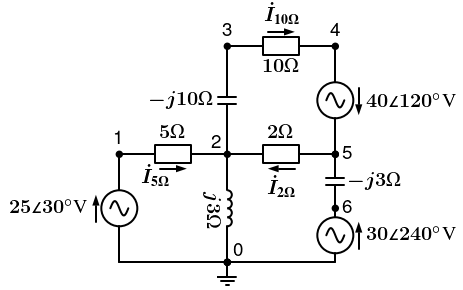

In [1]:
%%writefile '2026Q9_5.spice'
2026C1Q9-5
V1 1 0 DC 0 AC 25 30
R1 1 2 5
L1 2 0 3m
C2 2 3 100u
R2 3 4 10
V2 5 4 DC 0 AC 40 120
R3 2 5 2
C3 5 6 333.3u
V3 6 0 DC 0 AC 30 240
.ac lin 1 159.1549 159.1549
.probe alli
.print ac i(r2) v(2) v(5) v(2,5)
.end

Overwriting 2026Q9_5.spice


In [2]:
!ngspice -b 2026Q9_5.spice


Note: No compatibility mode selected!


Circuit: 2026c1q9-5

Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

Using SPARSE 1.3 as Direct Linear Solver

No. of Data Rows : 1
                                   2026c1q9-5
                                   AC Analysis  Mon May 18 16:33:37  2026
--------------------------------------------------------------------------------
Index   frequency       r2#branch                       
--------------------------------------------------------------------------------
0	1.591549e+02	-3.51148e+00,	2.094677e+00	

                                   2026c1q9-5
                                   AC Analysis  Mon May 18 16:33:37  2026
--------------------------------------------------------------------------------
Index   frequency       v(2)                            
--------------------------------------------------------------------------------
0	1.591549e+02	2.925069e+01,	-2.77358e+00	

                                   2026c1q9-5
    

## PySpiceでの解析
ネットリストを渡さず定義する方法もあるが面倒．

PySpiceはngspiceのライブラリ(libngspice)を使うので，インストール時はどのみちマニュアルに沿った作業が必要．
こっちの方が結果をすんなり別の何かに使い回せる．

In [3]:
import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()
from pprint import pprint

from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *
import matplotlib.pyplot as plt
import numpy as np
circuit = Circuit('test')
circuit.raw_spice = u'''V1 1 0 DC 0 AC 25 30
R1 1 2 5
L1 2 0 3m
C2 2 3 100u
R2 3 4 10
V2 5 4 DC 0 AC 40 120
R3 2 5 2
C3 5 6 333.3u
V3 6 0 DC 0 AC 30 240
.probe alli
'''
simulator = circuit.simulator(temperature=25, nominal_temperature=25)
res = simulator.ac(start_frequency=159.1549,stop_frequency=159.1549,number_of_points=1, variation='lin')
v2 = np.array(res.nodes['2'])
ir2 = np.array(res.branches['r2'])
print(v2,ir2)


2026-05-18 16:33:37,452 - PySpice.Spice.NgSpice.Shared.NgSpiceShared - Shared.WARNING - Warning: can't find the initialization file spinit.
2026-05-18 16:33:37,454 - PySpice.Spice.NgSpice.Shared.NgSpiceShared - Shared.WARNING - Unsupported Ngspice version 46
[29.25069463-2.77358372j] [-3.51147854+2.09467693j]


In [4]:
res.branches

{'v1': WaveForm v1 [1.52001191-3.05471674j]@A,
 'r1': WaveForm r1 [-1.52001191+3.05471674j]@A,
 'l1': WaveForm l1 [-0.92452816-9.75023418j]@A,
 'c2': WaveForm c2 [-3.51147854+2.09467693j]@A,
 'r2': WaveForm r2 [-3.51147854+2.09467693j]@A,
 'v2': WaveForm v2 [3.51147854-2.09467693j]@A,
 'r3': WaveForm r3 [2.91599479+10.710274j]@A,
 'c3': WaveForm c3 [-0.59548375+12.80495093j]@A,
 'v3': WaveForm v3 [-0.59548375+12.80495093j]@A}

In [5]:
res.nodes

{'6': WaveForm 6 [-15.-25.98076211j]@V,
 '5': WaveForm 5 [23.41870505-24.19413172j]@V,
 '4': WaveForm 4 [43.41870505-58.83514787j]@V,
 '3': WaveForm 3 [8.30391968-37.8883786j]@V,
 '2': WaveForm 2 [29.25069463-2.77358372j]@V,
 '1': WaveForm 1 [21.65063509+12.5j]@V}

## 「節点」の扱い
3つ以上の素子が繋がっている主要節点という話をしたが，手計算のコストの都合であり，2つ以上の素子が繋がるSPICE的な「節点」で節点電圧方程式を立ててもよい．
例えばこの回路で手計算なら
$$\left(\frac{1}{10}+\frac{1}{-j5}+\frac{1}{3+j4}\right)\dot{V}_{1}=5$$
だが'2'も節点とすれば
$$\left[\begin{array}{cc}\frac{1}{10}+\frac{1}{-j5}+\frac{1}{3}&-\frac{1}{3}\\-\frac{1}{3}&\frac{1}{3}+\frac{1}{j4} \end{array}\right]\left[\begin{array}{c} \dot{V}_{1}\\ \dot{V}_{2}\end{array}\right]=\left[\begin{array}{c} 5\\ 0\end{array}\right]$$
となる．それぞれ求めれば節点1の電圧は同じ結果となる．

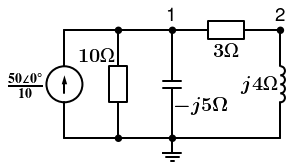

In [6]:
import numpy as np
A = 1/10+1/(-5j)+1/(3+4j)
B = 5
ans = B/A
print('V1:',ans)
print('V2:',ans*4j/(3+4j))

V1: (22-4.000000000000001j)
V2: (16+8j)


In [7]:
import numpy as np
A = np.array([
    [ 1/10+1/(-5j)+1/3, -1/3],
    [-1/3, 1/3+1/(4j)]])
B = np.array([5,0])
ans = np.linalg.solve(A,B)
print (ans)

[22.-4.j 16.+8.j]


## 修正節点電圧法

節点電圧法は節点に繋がるアドミタンスの和としているが，枝電流を未知数とする場合にはアドミタンスの和には含めず，枝電流のスタンプのルールに従う

($\dot{I}_b$は$-j5\Omega$に流れる電流)

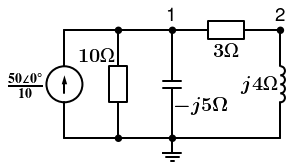


$$\left[
\begin{array}{cccc}\frac{1}{10}+\frac{1}{3}&-\frac{1}{3}&-\frac{1}{10}&1\\
-\frac{1}{3}&\frac{1}{3}+\frac{1}{j4}&-\frac{1}{j4} &0\\
-\frac{1}{10}&-\frac{1}{j4}&\frac{1}{10}+\frac{1}{j4}&-1\\
\frac{1}{-j5}&0&-\frac{1}{-j5}&-1
\end{array}
\right]\left[\begin{array}{c} \dot{V}_{1}\\ \dot{V}_{2}\\\dot{V}_{0}\\\dot{I}_{b}\end{array}\right]=\left[\begin{array}{c} 5\\ 0\\0\\0\end{array}\right]$$

In [8]:
import numpy as np
A = np.array([
    [ 1/10+1/3, -1/3,-1/10,1],
    [-1/3, 1/3+1/(4j), -1/(4j),0],
    [-1/10,-1/(4j),1/10+1/(4j),-1],
    [1/(-5j),0,-(1/(-5j)),-1]])           
# A2 = np.delete(A,3,axis=0)
# A2 = np.delete(A2,3,axis=1)
A2 = np.delete(A,2,axis=0)
A2 = np.delete(A2,2,axis=1)
B = np.array([5,0,-5,0])
# B2 = np.delete(B,3)
B2 = np.delete(B,2)
#ans = np.linalg.solve(A,B)
ans = np.linalg.solve(A2,B2)
print (ans)

[22. -4.j  16. +8.j   0.8+4.4j]


枝電流を増やすと

($\dot{I}_b$は$-j5\Omega$に流れる電流, $\dot{I}_c$は$3\Omega$に流れる電流)

$$\left[
\begin{array}{ccccc}\frac{1}{10}&0&-\frac{1}{10}&1&1\\
0&\frac{1}{j4}&-\frac{1}{j4} &0&-1\\
-\frac{1}{10}&-\frac{1}{j4}&\frac{1}{10}+\frac{1}{j4}&-1&0\\
\frac{1}{-j5}&0&-\frac{1}{-j5}&-1&0\\
\frac{1}{3}&-\frac{1}{3}&0&0&-1
\end{array}
\right]\left[\begin{array}{c} \dot{V}_{1}\\ \dot{V}_{2}\\\dot{V}_{0}\\\dot{I}_{b}\\\dot{I}_{c}\end{array}\right]=\left[\begin{array}{c} 5\\ 0\\0\\0\\0\end{array}\right]$$

In [9]:
import numpy as np
A = np.array([
    [ 1/10, 0,-1/10,1,1],
    [0, 1/(4j), -1/(4j),0,-1],
    [-1/10,-1/(4j),1/10+1/(4j),-1,0],
    [1/(-5j),0,-(1/(-5j)),-1,0],
    [1/3,-1/3,0,0,-1]])           
# A2 = np.delete(A,3,axis=0)
# A2 = np.delete(A2,3,axis=1)
A2 = np.delete(A,2,axis=0)
A2 = np.delete(A2,2,axis=1)
B = np.array([5,0,-5,0,0])
# B2 = np.delete(B,3)
B2 = np.delete(B,2)
#ans = np.linalg.solve(A,B)
ans = np.linalg.solve(A2,B2)
print (ans)

[22. -4.j  16. +8.j   0.8+4.4j  2. -4.j ]


更に増やした場合(直列なので同値が出る)

($\dot{I}_b$は$-j5\Omega$に流れる電流, $\dot{I}_c$は$3\Omega$に流れる電流, $\dot{I}_{j4}$は$j4\Omega$に流れる電流)


$$\left[
\begin{array}{ccccc}\frac{1}{10}&0&-\frac{1}{10}&1&1&0\\
0&0&0 &0&-1&1\\
-\frac{1}{10}&0&\frac{1}{10}&-1&0&-1\\
\frac{1}{-j5}&0&-\frac{1}{-j5}&-1&0&0\\
\frac{1}{3}&-\frac{1}{3}&0&0&-1&0\\
0&\frac{1}{j4}&-\frac{1}{j4}&0&0&-1
\end{array}
\right]\left[\begin{array}{c} \dot{V}_{1}\\ \dot{V}_{2}\\\dot{V}_{0}\\\dot{I}_{b}\\\dot{I}_{c}\\\dot{I}_{j4}\end{array}\right]=\left[\begin{array}{c} 5\\ 0\\0\\0\\0\\0\end{array}\right]$$

In [10]:
import numpy as np
A = np.array([
    [ 1/10, 0,-1/10,1,1,0],
    [0, 0, 0,0,-1,1],
    [-1/10,0,1/10,-1,0,-1],
    [1/(-5j),0,-(1/(-5j)),-1,0,0],
    [1/3,-1/3,0,0,-1,0],
    [0,1/(4j),-1/(4j),0,0,-1]])           
# A2 = np.delete(A,3,axis=0)
# A2 = np.delete(A2,3,axis=1)
A2 = np.delete(A,2,axis=0)
A2 = np.delete(A2,2,axis=1)
B = np.array([5,0,-5,0,0,0])
# B2 = np.delete(B,3)
B2 = np.delete(B,2)
#ans = np.linalg.solve(A,B)
ans = np.linalg.solve(A2,B2)
print (ans)

[22. -4.j  16. +8.j   0.8+4.4j  2. -4.j   2. -4.j ]


## 電圧源だけの場合の修正節点電圧法
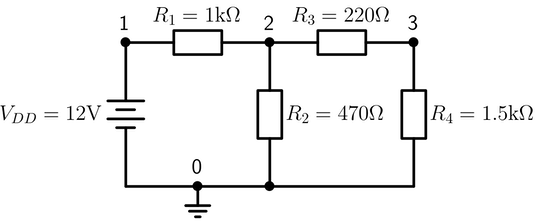
$
\begin{bmatrix} 
G_1&-G_1&0&0&1\\
-G_1&G_1+G_2+G_3&-G_3&-G_2&0\\
0&-G_3&G_3+G_4&-G_4&0\\
0&-G_2&-G_4&G_2+G_4&-1\\
-1&0&0&1&0
\end{bmatrix}
\begin{bmatrix}
V_1\\ V_2\\ V_3\\ V_0 \\ I_{V_{DD}}
\end{bmatrix}
= \begin{bmatrix}
0\\0\\0\\0\\-V_{DD}
\end{bmatrix}
$

のように式が出来たら接地の行と列(4行めと4列め)を削除する

$
\begin{bmatrix} 
G_1&-G_1&0&1\\
-G_1&G_1+G_2+G_3&-G_3&0\\
0&-G_3&G_3+G_4&0\\
-1&0&0&0
\end{bmatrix}
\begin{bmatrix}
V_1\\ V_2\\ V_3\\ I_{V_{DD}}
\end{bmatrix}
= \begin{bmatrix}
0\\0\\0\\-V_{DD}
\end{bmatrix}
$

In [11]:
from sympy import symbols, Matrix, I
G1, G2, G3, G4, VDD = symbols('G_1 G_2 G_3 G_4 V_{DD}')
Y = Matrix([[G1, -G1, 0, 1],
            [-G1,G1+G2+G3,-G3,0],
            [0,-G3,G3+G4,0],
            [-1,0,0,0]])
IV = Matrix([[0],[0],[0],
             [-VDD]])
display(Y)
display(IV)
Yf = Y.subs([(G1,1/1e3),(G2,1/470),(G3,1/220),(G4,1/1.5e3),(VDD,12)])
IVf = IV.subs([(G1,1/1e3),(G2,1/470),(G3,1/220),(G4,1/1.5e3),(VDD,12)])
display(Yf)
ans,p = Yf.row_join(IVf).rref()
display(ans)

print('素直にnumpyを使った場合')
import numpy as np
G1 = 1/1e3
G2 = 1/470
G3 = 1/220
G4 = 1/1.5e3
VDD = 12
Y = np.array([[G1, -G1, 0,  1],
            [-G1,G1+G2+G3,-G3,0],
            [0,-G3,G3+G4,0],
            [-1,0,0,0]])
IV = np.array([[0],[0],[0],[-VDD]])
np.linalg.solve(Y,IV)

Matrix([
[ G_1,            -G_1,         0, 1],
[-G_1, G_1 + G_2 + G_3,      -G_3, 0],
[   0,            -G_3, G_3 + G_4, 0],
[  -1,               0,         0, 0]])

Matrix([
[      0],
[      0],
[      0],
[-V_{DD}]])

Matrix([
[ 0.001,               -0.001,                    0, 1],
[-0.001,  0.00767311411992263, -0.00454545454545455, 0],
[     0, -0.00454545454545455,  0.00521212121212121, 0],
[    -1,                    0,                    0, 0]])

Matrix([
[1, 0, 0, 0,                   12],
[0, 1, 0, 0,     3.23532550693703],
[0, 0, 1, 0,     2.82150480256136],
[0, 0, 0, 1, -0.00876467449306297]])

素直にnumpyを使った場合


array([[ 1.20000000e+01],
       [ 3.23532551e+00],
       [ 2.82150480e+00],
       [-8.76467449e-03]])

## 電圧源の回路で枝電流がある場合の修正節点電圧法

人力スタンプの限界に近い．だんだんとSparse-Tableau法に近付いてくる．
電圧源の電流が逆向きになるところ含めてSPICEと同様の結果になる．

($\dot{I}_V$は電圧源に流れる電流だが計算の都合上逆向きになる)

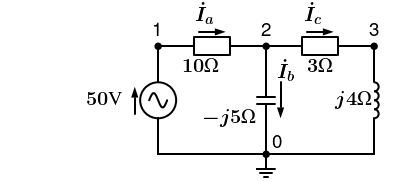


$$\left[
\begin{array}{ccccccccc}
0&0&0&0&1&1&0&0&0 \\
0&0&0&0&0&-1&1&1&0 \\
0&0&0&0&0&0&0&-1&1 \\
0&0&0&0&-1&0&-1&0&-1 \\
-1&0&0&1&0&0&0&0&0\\
\frac{1}{10}&-\frac{1}{10}&0&0&0&-1&0&0&0\\
0&\frac{1}{-j5}&0&-\frac{1}{-j5}&0&0&-1&0&0\\
0&\frac{1}{3}&-\frac{1}{3}&0&0&0&0&-1&0\\
0&0&\frac{1}{j4}&-\frac{1}{j4}&0&0&0&0&-1
\end{array}
\right]
\left[
\begin{array}{c}
\dot{V}_1\\\dot{V}_2\\\dot{V}_3\\\dot{V}_0\\\dot{I}_V\\\dot{I}_a\\\dot{I}_b\\\dot{I}_c\\\dot{I}_{j4}
\end{array}
\right]=
\left[
\begin{array}{c}
0\\0\\0\\0\\-50\\0\\0\\0\\0
\end{array}
\right]
$$

In [12]:
import numpy as np
A = np.array([
    [0,0,0,0,1,1,0,0,0],
    [0,0,0,0,0,-1,1,1,0],
    [0,0,0,0,0,0,0,-1,1],
    [0,0,0,0,-1,0,-1,0,-1],
    [-1,0,0,1,0,0,0,0,0],
    [1/10,-1/10,0,0,0,-1,0,0,0],
    [0,1/(-5j),0,-1/(-5j),0,0,-1,0,0],
    [0,1/3,-1/3,0,0,0,0,-1,0],
    [0,0,1/(4j),-1/(4j),0,0,0,0,-1]])
B = np.array([0,0,0,0,-50,0,0,0,0])
A2 = np.delete(A,3,axis=0)
A2 = np.delete(A2,3,axis=1)
B2 = np.delete(B,3)
np.linalg.solve(A2,B2)

array([50. +0.j , 22. -4.j , 16. +8.j , -2.8-0.4j,  2.8+0.4j,  0.8+4.4j,
        2. -4.j ,  2. -4.j ])